In [1]:
import matplotlib.pyplot as plt
import pickle
from LiH import K, E_fcis

/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: On GPUs an efficient choice is to run ~512 Markov Chains per GPU.

LiH 分子基本信息
HF energy = -7.86245187 Ha
Total electrons = (2, 2)
Total basis functions = 6

Total orbitals in STO-3G: 6

LiH / STO-3G 基准能量
E0 = -7.88259092 Ha | excitation = 0.0000 eV
E1 = -7.76563664 Ha | excitation = 3.1825 eV
E2 = -7.74858736 Ha | excitation = 3.6464 eV
E3 = -7.71601970 Ha | excitation = 4.5326 eV
E4 = -7.71601970 Ha | excitation = 4.5326 eV
E5 = -7.69619638 Ha | excitation = 5.0721 eV
E6 = -7.69619638 Ha | excitation = 5.0721 eV
E7 = -7.47817401 Ha | excitation = 11.0048 eV
E8 = -7.31633742 Ha | excitation = 15.4086 eV
E9 = -7.29675800 Ha | excitation = 15.9413 eV

Active Space Configuration:
  n_orbitals = 4
  n_alpha = 2, n_beta = 2
  Total electrons = (2, 2)

Hilbert 信息
K = 4
hi.size = 8
hi_ext.size = 32
SINGLE_SIZE = 8
target_loss = sum(E_fcis[:K]) = -31.11283462

HF reference state: [0 0 1 1 0 0 1 1]
Alpha orbitals: [0, 1, 2, 3]... (4 total)
Beta orbitals: [4, 5, 6, 7]... (4 total)

Single edges (total): 12


In [2]:
with open('./data/26-09-01-05-57_history_natural_gradient_LiH_molecule_K4.pkl', 'rb') as f:
    history = pickle.load(f)
history.keys()

dict_keys(['steps', 'logpsi_mean', 'logpsi_min', 'logpsi_max', 'grad_norm_raw', 'grad_norm_natural', 'E_L_real', 'E_L_imag', 'loss', 'first_step', 'save_interval'])

KeyError: 'Energy_levels'

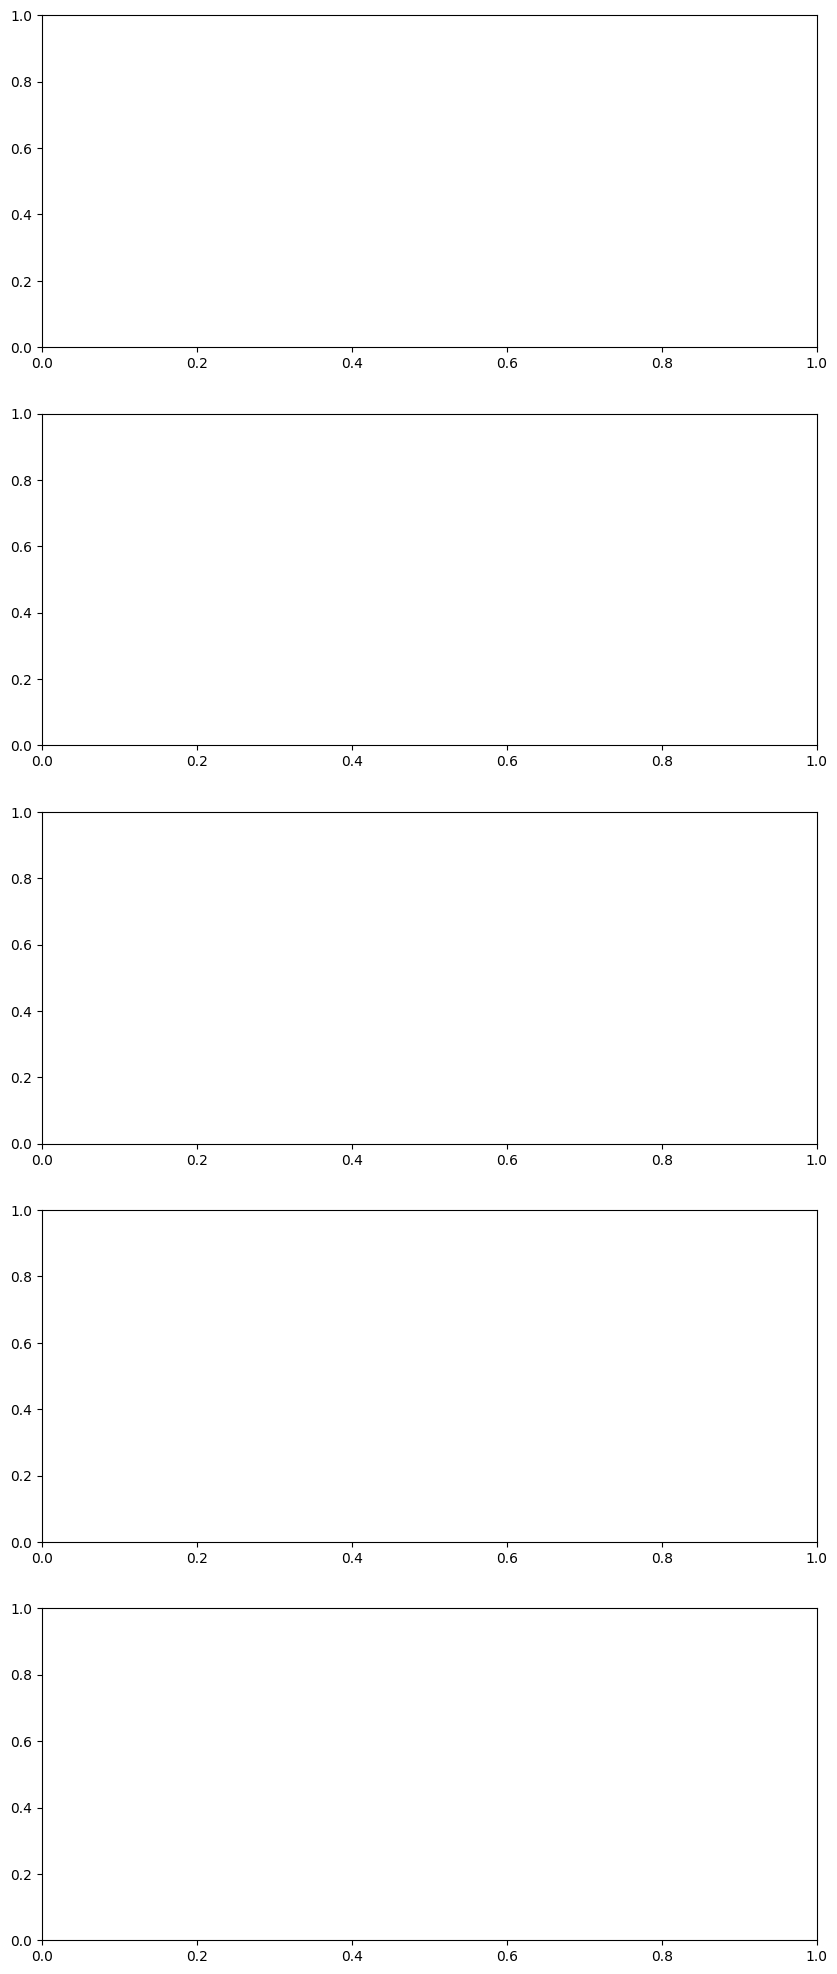

In [3]:
fig,axs = plt.subplots(5, 1, figsize=(10, 25))
axs[0].plot(history['steps'],history["Energy_levels"])
for i in E_fcis:
    axs[0].axhline(i, color='gray', ls='--', alpha=0.4)

axs[0].set_ylabel("Energy")
axs[1].plot(history['steps'],history["loss"])
axs[1].set_ylabel("Loss")
axs[2].plot(history['steps'],history["logpsi_mean"])
axs[2].set_ylabel("logpsi_mean")
axs[3].plot(history['steps'],history["grad_norm_raw"])
axs[3].set_ylabel("grad_norm_raw")
axs[4].plot(history['steps'],history["grad_norm_per_param"])
axs[4].set_ylabel("grad_norm_per_param")


In [ ]:

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(history['steps'],history["Energy_levels"])

for energy_index in range(K):
    ax.axhline(E_fcis[energy_index],linestyle="--", alpha=0.7, label=f"$E_{energy_index}$ (CAS Exact)")



ax.set_ylabel("Energy")
ax.set_xlabel("Steps")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig,axs = plt.subplots(5, 1, figsize=(10, 25))

# ===== 竖线位置：每隔10个采样点 =====
vline_x = history['steps'][::10]

axs[0].plot(history['steps'], history["Energy_levels"])
axs[0].set_ylabel("Energy")
for x in vline_x:
    axs[0].axvline(x, color='gray', ls='--', alpha=0.4)

axs[1].plot(history['steps'], history["loss"])
axs[1].set_ylabel("Loss")
for x in vline_x:
    axs[1].axvline(x, color='gray', ls='--', alpha=0.4)

axs[2].plot(history['steps'], history["logpsi_mean"])
axs[2].set_ylabel("logpsi_mean")
for x in vline_x:
    axs[2].axvline(x, color='gray', ls='--', alpha=0.4)

axs[3].plot(history['steps'], history["grad_norm_raw"])
axs[3].set_ylabel("grad_norm_raw")
for x in vline_x:
    axs[3].axvline(x, color='gray', ls='--', alpha=0.4)

axs[4].plot(history['steps'], history["grad_norm_per_param"])
axs[4].set_ylabel("grad_norm_per_param")
for x in vline_x:
    axs[4].axvline(x, color='gray', ls='--', alpha=0.4)

plt.tight_layout()
plt.show()
